## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, models

## Load Dataset

In [2]:
dataset_path = Path("../dataset")
dl_data_path = dataset_path / "dl_data"

X_train = np.load(dl_data_path / "X_train.npy")
X_validation = np.load(dl_data_path / "X_validation.npy")
X_test = np.load(dl_data_path / "X_test.npy")

y_train = np.load(dl_data_path / "y_train.npy")
y_validation = np.load(dl_data_path / "y_validation.npy")
y_test = np.load(dl_data_path / "y_test.npy")

print("===== Datasets loaded successfully. =====")

===== Datasets loaded successfully. =====


## Preprocessing & Normalization

In [3]:
X_train = X_train.astype(np.float32)
X_validation = X_validation.astype(np.float32)
X_test = X_test.astype(np.float32)

# Calculate statistics only from training data
train_mean = X_train.mean()
train_std = X_train.std()

# Normalize
X_train = (X_train - train_mean) / train_std
X_validation = (X_validation - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

print("===== NORMALIZATION CHECK =====")

print("Train:")
print("Mean:", X_train.mean())
print("Std:", X_train.std())

print("\nValidation:")
print("Mean:", X_validation.mean())
print("Std:", X_validation.std())

print("\nTest:")
print("Mean:", X_test.mean())
print("Std:", X_test.std())

===== NORMALIZATION CHECK =====
Train:
Mean: 8.628554e-08
Std: 1.0000006

Validation:
Mean: 0.00015843338
Std: 1.0341631

Test:
Mean: 0.0026376029
Std: 1.0162377


## Add Channel Dimension

In [4]:
X_train = X_train[..., np.newaxis]
X_validation = X_validation[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("\n===== TRANSFORMER INPUT SHAPES =====")

print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)


===== TRANSFORMER INPUT SHAPES =====
X_train: (5969, 9000, 1)
X_validation: (1279, 9000, 1)
X_test: (1280, 9000, 1)


## Transformer Encoder Block

In [5]:
def transformer_encoder_block(
    x,
    num_heads=4,
    key_dim=32,
    ff_dim=256,
    dropout=0.1
):
    
    # Multi-Head Self Attention
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        dropout=dropout
    )(x, x)

    # Residual connection
    x = layers.Add()([
        x,
        attention_output
    ])

    # Layer Normalization
    x = layers.LayerNormalization(
        epsilon=1e-6
    )(x)

    # Feed Forward Network
    ff_output = layers.Dense(
        ff_dim,
        activation="gelu"
    )(x)

    ff_output = layers.Dropout(
        dropout
    )(ff_output)

    ff_output = layers.Dense(
        x.shape[-1]
    )(ff_output)

    # Residual connection
    x = layers.Add()([
        x,
        ff_output
    ])

    # Layer Normalization
    x = layers.LayerNormalization(
        epsilon=1e-6
    )(x)

    return x

## Positional Embedding

In [11]:
class PositionalEmbedding(layers.Layer):

    def __init__(
        self,
        sequence_length,
        embedding_dim,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.sequence_length = sequence_length
        self.embedding_dim = embedding_dim

        self.position_embedding = layers.Embedding(
            input_dim=sequence_length,
            output_dim=embedding_dim
        )

    def call(self, inputs):

        positions = tf.range(
            start=0,
            limit=self.sequence_length,
            delta=1
        )

        positions = self.position_embedding(
            positions
        )

        return inputs + positions

    def get_config(self):

        config = super().get_config()

        config.update({
            "sequence_length": self.sequence_length,
            "embedding_dim": self.embedding_dim
        })

        return config

## Build 1D Transformer Model

In [12]:
inputs = layers.Input(
    shape=(9000, 1)
)

x = inputs


# =========================================================
# Patch Embedding
# =========================================================

# Convert the ECG signal into temporal patches
#
# 9000 samples
#       ↓
# kernel_size = 50
# stride = 50
#       ↓
# 180 patches
#
# Each patch is represented by 128 features.

x = layers.Conv1D(
    filters=128,
    kernel_size=50,
    strides=50,
    padding="valid"
)(x)


# =========================================================
# Layer Normalization
# =========================================================

x = layers.LayerNormalization(
    epsilon=1e-6
)(x)


# =========================================================
# Positional Embedding
# =========================================================

x = PositionalEmbedding(
    sequence_length=180,
    embedding_dim=128
)(x)


# =========================================================
# Transformer Encoder Block 1
# =========================================================

x = transformer_encoder_block(
    x,
    num_heads=4,
    key_dim=32,
    ff_dim=256,
    dropout=0.1
)


# =========================================================
# Transformer Encoder Block 2
# =========================================================

x = transformer_encoder_block(
    x,
    num_heads=4,
    key_dim=32,
    ff_dim=256,
    dropout=0.1
)


# =========================================================
# Transformer Encoder Block 3
# =========================================================

x = transformer_encoder_block(
    x,
    num_heads=4,
    key_dim=32,
    ff_dim=256,
    dropout=0.1
)


# =========================================================
# Global Average Pooling
# =========================================================

x = layers.GlobalAveragePooling1D()(x)


# =========================================================
# Fully Connected Layer
# =========================================================

x = layers.Dense(
    64,
    activation="relu"
)(x)

x = layers.Dropout(
    0.2
)(x)


# =========================================================
# Output Layer
# =========================================================

outputs = layers.Dense(
    4,
    activation="softmax"
)(x)


# =========================================================
# Create Model
# =========================================================

model = models.Model(
    inputs=inputs,
    outputs=outputs,
    name="1D_Transformer"
)

model.summary()

Model: "1D_Transformer"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 9000, 1)]    0           []                               
                                                                                                  
 conv1d_1 (Conv1D)              (None, 180, 128)     6528        ['input_2[0][0]']                
                                                                                                  
 layer_normalization_7 (LayerNo  (None, 180, 128)    256         ['conv1d_1[0][0]']               
 rmalization)                                                                                     
                                                                                                  
 positional_embedding_1 (Positi  (None, 180, 128)    23040       ['layer_normalizatio

## Compile Model

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


## Callbacks

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    "best_1d_transformer_unweighted.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

print("Callbacks created successfully.")

Callbacks created successfully.


## Train Model

In [23]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(
        X_validation,
        y_validation
    ),
    epochs=50,
    batch_size=8,
    callbacks=[
        early_stopping,
        model_checkpoint
    ],
    verbose=1
)

Epoch 1/50
746/747 [============================>.] - ETA: 0s - loss: 1.0151 - accuracy: 0.5915
Epoch 1: val_loss did not improve from 0.98039
747/747 [==============================] - 24s 32ms/step - loss: 1.0150 - accuracy: 0.5916 - val_loss: 1.0150 - val_accuracy: 0.5950
Epoch 2/50
745/747 [============================>.] - ETA: 0s - loss: 1.0085 - accuracy: 0.5951
Epoch 2: val_loss did not improve from 0.98039
747/747 [==============================] - 24s 32ms/step - loss: 1.0085 - accuracy: 0.5951 - val_loss: 0.9930 - val_accuracy: 0.5950
Epoch 3/50
747/747 [==============================] - ETA: 0s - loss: 1.0066 - accuracy: 0.5952
Epoch 3: val_loss did not improve from 0.98039
747/747 [==============================] - 21s 28ms/step - loss: 1.0066 - accuracy: 0.5952 - val_loss: 0.9948 - val_accuracy: 0.5950
Epoch 4/50
746/747 [============================>.] - ETA: 0s - loss: 1.0018 - accuracy: 0.5952
Epoch 4: val_loss did not improve from 0.98039
747/747 [====================

## Test Evaluation

In [24]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("===== 1D TRANSFORMER TEST RESULTS =====")

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

40/40 [==============================] - 1s 27ms/step - loss: 0.9745 - accuracy: 0.5953
===== 1D TRANSFORMER TEST RESULTS =====
Test Loss: 0.9745
Test Accuracy: 0.5953


## Predictions & Confusion Matrix

In [25]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

y_pred_prob = model.predict(
    X_test,
    verbose=1
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

cm = confusion_matrix(
    y_test,
    y_pred
)

print("===== TRANSFORMER CONFUSION MATRIX =====")
print(cm)

40/40 [==============================] - 1s 22ms/step
===== TRANSFORMER CONFUSION MATRIX =====
[[762   0   0   0]
 [112   0   1   0]
 [363   0   0   0]
 [ 42   0   0   0]]


## Plot Confusion Matrix

<Figure size 700x600 with 0 Axes>

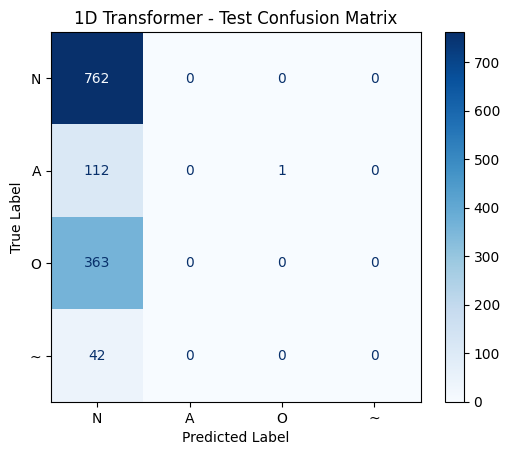

In [26]:
class_names = [
    "N",
    "A",
    "O",
    "~"
]

plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title(
    "1D Transformer - Test Confusion Matrix"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## Classification Report

In [27]:
print("===== 1D TRANSFORMER CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

===== 1D TRANSFORMER CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           N     0.5958    1.0000    0.7467       762
           A     0.0000    0.0000    0.0000       113
           O     0.0000    0.0000    0.0000       363
           ~     0.0000    0.0000    0.0000        42

    accuracy                         0.5953      1280
   macro avg     0.1489    0.2500    0.1867      1280
weighted avg     0.3547    0.5953    0.4445      1280



c:\Users\Anexpectant\Documents\aut\karshenasi\final_project\projects\main_project\Single_Lead_ECG_AF_Classification\.venv_gpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Anexpectant\Documents\aut\karshenasi\final_project\projects\main_project\Single_Lead_ECG_AF_Classification\.venv_gpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Anexpectant\Documents\aut\karshenasi\final_project\projects\main_project\Single_Lead_ECG_AF_Classification\.venv_gpu\lib\site-packages\sklear

## Loss Curve

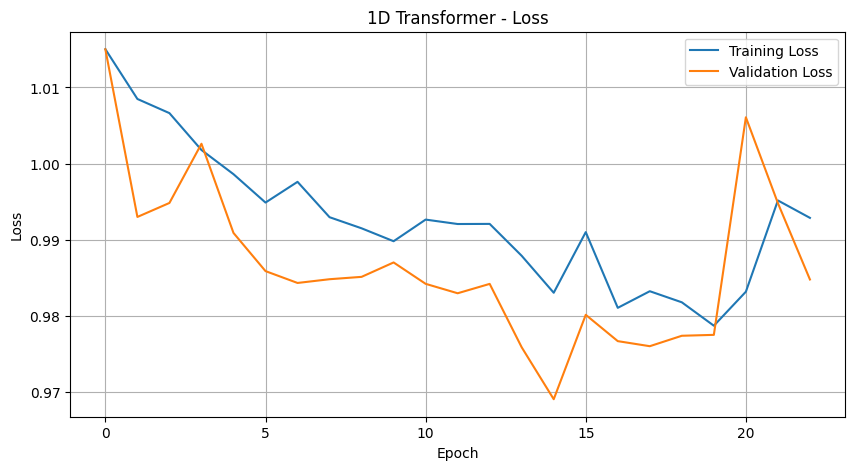

In [28]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "1D Transformer - Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid()

plt.show()

## Accuracy Curve

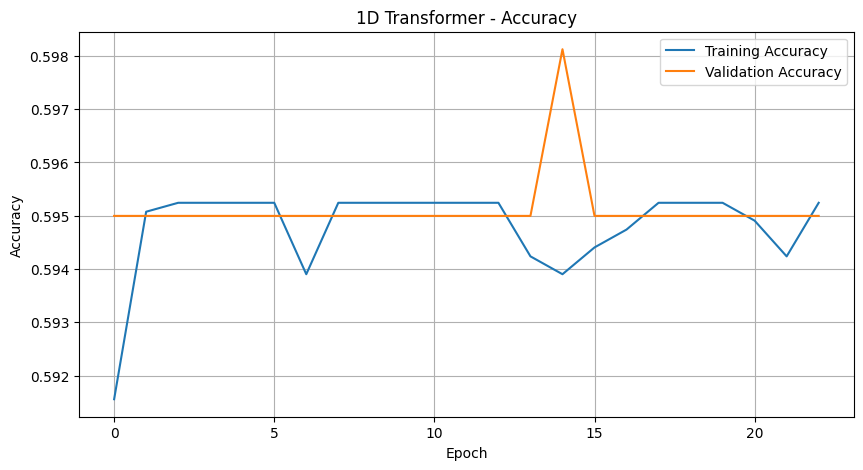

In [29]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "1D Transformer - Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid()

plt.show()

## Final Test Metrics

In [30]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

macro_precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("==========================================")
print("       1D TRANSFORMER FINAL RESULTS")
print("==========================================")

print(f"Test Loss       : {test_loss:.4f}")
print(f"Test Accuracy   : {test_accuracy:.4f}")
print(f"Macro Precision : {macro_precision:.4f}")
print(f"Macro Recall    : {macro_recall:.4f}")
print(f"Macro F1        : {macro_f1:.4f}")
print(f"Weighted F1     : {weighted_f1:.4f}")

print("==========================================")

       1D TRANSFORMER FINAL RESULTS
Test Loss       : 0.9745
Test Accuracy   : 0.5953
Macro Precision : 0.1489
Macro Recall    : 0.2500
Macro F1        : 0.1867
Weighted F1     : 0.4445
